In [5]:
# Save comparison CSV
import pandas as pd
import os

comp_path = os.path.join("./", "comparison_random_vs_kcenter.csv")
comp_df = pd.read_csv(comp_path)
kcenter_rows = comp_df[comp_df["source"] == 'kcenter']
random_rows = comp_df[comp_df["source"] == 'random']


import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
kc_df = pd.DataFrame(kcenter_rows).sort_values("matching_ratio")
rnd_df = pd.DataFrame(random_rows)
ratios_plot = sorted(kc_df["matching_ratio"].unique())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["pr_auc", "auc"]):
    ax.plot(kc_df["matching_ratio"], kc_df[metric], "o-", label="k-center (no weight)", color="C0", linewidth=2)
    rnd_agg = rnd_df.groupby("matching_ratio")[metric].agg(["mean", "std"])
    rnd_agg = rnd_agg.reindex(ratios_plot)
    means = rnd_agg["mean"].values
    stds = rnd_agg["std"].values
    ax.errorbar(ratios_plot, means, yerr=stds, fmt="s--", capsize=4, label=f"random (5 seeds)", color="C1")
    ax.set_xlabel("Matching ratio (1:k)")
    ax.set_ylabel(metric.upper().replace("_", "-"))
    ax.set_xticks(ratios_plot)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("XGB default (no class weight): k-center vs random same-size undersample")
plt.tight_layout()
comp_plot_path = os.path.join("./random_vs_kcenter_auc_pr_auc_xgb.png")
plt.savefig(comp_plot_path, dpi=150)
plt.close()
print(f"Saved comparison plot to {comp_plot_path}")
# Plot: Recall(G-mean), specificity(G-mean), recall(MCC), specificity(MCC), recall(F1), specificity(F1) - k-center line vs random mean ± std
kc_df = pd.DataFrame(kcenter_rows).sort_values("matching_ratio")
rnd_df = pd.DataFrame(random_rows)
ratios_plot = sorted(kc_df["matching_ratio"].unique())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric in zip(axes, [("recall_at_gmean", "specificity_at_gmean"), ("recall_at_mcc", "specificity_at_mcc"), ("recall_at_f1", "specificity_at_f1")]):
    ax.plot(kc_df["matching_ratio"], kc_df[metric[0]], "o-", label="recall (k-center)", color="C0", linewidth=2)
    ax.plot(kc_df["matching_ratio"], kc_df[metric[1]], "s-", label="specificity (k-center)", color="C0", linewidth=2)
    rnd_agg = rnd_df.groupby("matching_ratio")[metric[0]].agg(["mean", "std"])
    rnd_agg2 = rnd_df.groupby("matching_ratio")[metric[1]].agg(["mean", "std"])
    rnd_agg = rnd_agg.reindex(ratios_plot)
    rnd_agg2 = rnd_agg2.reindex(ratios_plot)
    means, means2 = rnd_agg["mean"].values, rnd_agg2["mean"].values
    stds, stds2 = rnd_agg["std"].values, rnd_agg2["std"].values
    ax.errorbar(ratios_plot, means, yerr=stds, fmt="o--", capsize=4, label=f"recall (random)", color="C1")
    ax.errorbar(ratios_plot, means2, yerr=stds2, fmt="s--", capsize=4, label=f"specificity (random)", color="C1")
    ax.set_xlabel("Matching ratio (1:k)")
    ax.set_ylabel(metric[0].upper().replace("_", "-"))
    ax.set_xticks(ratios_plot)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("XGB default (no class weight): k-center vs random same-size undersample")
plt.tight_layout()
comp_plot_path = os.path.join("./random_vs_kcenter_recall_xgb.png")
plt.savefig(comp_plot_path, dpi=150)
plt.close()
print(f"Saved comparison plot to {comp_plot_path}")


Saved comparison plot to ./random_vs_kcenter_auc_pr_auc_xgb.png
Saved comparison plot to ./random_vs_kcenter_recall_xgb.png


Text(0.5, 1.03, 'Experiment Landscape (Recall–Precision plane; color = PR-AUC)')

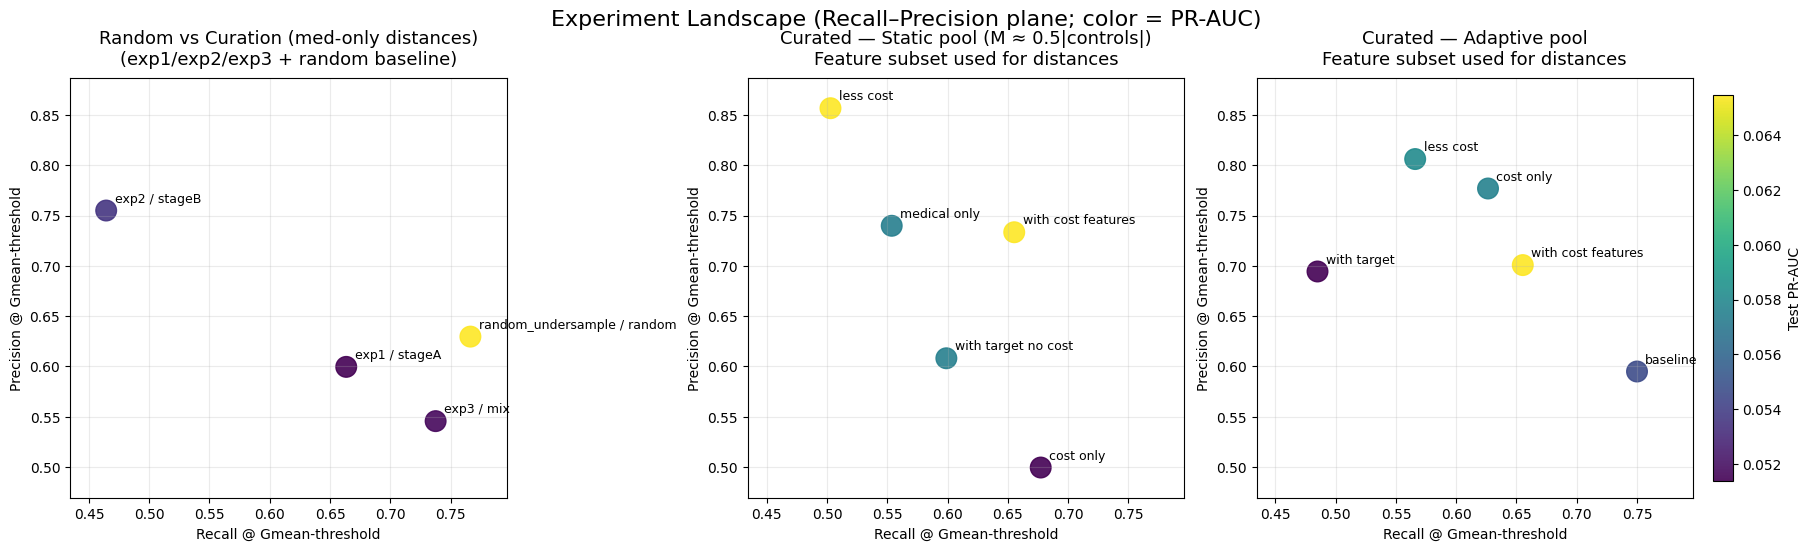

In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

df_exp=pd.read_csv("exp_random_vs_curation_medical_only_features/results/experiment_summary.csv")
df_static=pd.read_csv("two_stage_undersampled_dfs/feature_subset_comparison_results_static_pool.csv")
df_adapt=pd.read_csv("two_stage_undersampled_dfs/feature_subset_comparison_results.csv")

def agg(df, group_cols):
    agg_cols=["auc","pr_auc","best_mcc","balanced_recall_gmean","balanced_specificity_gmean","optimal_f1"]
    out=(df.groupby(group_cols)[agg_cols]
           .agg(["mean","std","count"])
           .reset_index())
    # flatten
    out.columns=["_".join([c for c in col if c]) for col in out.columns.values]
    return out

exp_agg=agg(df_exp, ["experiment","variant"])
static_agg=agg(df_static, ["feature_subset","distance_dir"])
adapt_agg=agg(df_adapt, ["feature_subset","distance_dir"])

import matplotlib.pyplot as plt, numpy as np, pandas as pd, textwrap, os

def make_panel(ax, df, title, label_col):
    x=df["balanced_recall_gmean_mean"].values 
    y=df["balanced_specificity_gmean_mean"].values
    c=df["pr_auc_mean"].values
    sc=ax.scatter(x,y,c=c,s=220,alpha=0.9)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Recall @ Gmean-threshold")
    ax.set_ylabel("Precision @ Gmean-threshold")
    ax.grid(True, alpha=0.25)
    # annotations
    for xi, yi, lab in zip(x,y,df[label_col].astype(str).values):
        ax.annotate(lab, (xi,yi), textcoords="offset points", xytext=(6,6), fontsize=9)
    return sc

# prep labels
exp_plot=exp_agg.copy()
exp_plot["label"]=exp_plot["experiment"]+" / "+exp_plot["variant"]

static_plot=static_agg.copy()
static_plot["label"]=static_plot["feature_subset"]

adapt_plot=adapt_agg.copy()
adapt_plot["label"]=adapt_plot["feature_subset"]

fig, axes=plt.subplots(1,3, figsize=(18,5.2), constrained_layout=True)
sc1=make_panel(axes[0], exp_plot, "Random vs Curation (med-only distances)\n(exp1/exp2/exp3 + random baseline)", "label")
sc2=make_panel(axes[1], static_plot, "Curated — Static pool (M ≈ 0.5|controls|)\nFeature subset used for distances", "label")
sc3=make_panel(axes[2], adapt_plot, "Curated — Adaptive pool\nFeature subset used for distances", "label")

# common colorbar for PR-AUC
cbar=fig.colorbar(sc1, ax=axes, location="right", shrink=0.92, pad=0.01)
cbar.set_label("Test PR-AUC", rotation=90)

# harmonize axes limits for comparability
all_x=np.concatenate([exp_plot["balanced_recall_gmean_mean"], static_plot["balanced_recall_gmean_mean"], adapt_plot["balanced_recall_gmean_mean"]])
all_y=np.concatenate([exp_plot["balanced_specificity_gmean_mean"], static_plot["balanced_specificity_gmean_mean"], adapt_plot["balanced_specificity_gmean_mean"]])
xmin=max(0, float(all_x.min())-0.03); xmax=min(1, float(all_x.max())+0.03)
ymin=max(0, float(all_y.min())-0.03); ymax=min(1, float(all_y.max())+0.03)
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

fig.suptitle("Experiment Landscape (Recall–Precision plane; color = PR-AUC)", fontsize=16, y=1.03)





In [14]:
out_path="landscape_plot.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
out_path


'landscape_plot.png'